# Inspect Frozen-Encoder Geometry Learning

Notebook-local training loop for the geometry-focused transformer and optional SE3 refiner on top of a frozen FoldTree2 encoder. The loop reuses `learn_geometry_lightning.py` builders and `GeometryFocusedModule._compute_total_loss`, then visualizes the input/target geometry, coarse transformer reconstruction, and SE3-refined reconstruction after each epoch.

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import copy
import math
import os
import random
import sys
from types import SimpleNamespace

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
os.environ.setdefault("XDG_CACHE_HOME", "/tmp")

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from torch_geometric.loader import DataLoader

start = Path.cwd()
repo = next((p for p in [start, *start.parents] if (p / "foldtree2" / "learn_geometry_lightning.py").exists()), None)
if repo is None:
	repo = next((p for p in [start, *start.parents] if (p / "learn_geometry_lightning.py").exists()), None)
if repo is None:
	raise RuntimeError(f"Could not find foldtree2 repo above {start}")

os.chdir(repo)
os.environ.setdefault("PYTHONPATH", str(repo))
if str(repo) not in sys.path:
	sys.path.insert(0, str(repo))

from foldtree2 import learn_geometry_lightning as gl

torch.set_default_dtype(torch.float32)
if torch.cuda.is_available():
	torch.set_float32_matmul_precision("high")

print("repo:", repo)
print("python:", sys.executable)
print("cuda:", torch.cuda.is_available())

repo: /home/dmoi/projects/foldtree2
python: /home/dmoi/miniforge3/envs/foldtree2/bin/python
cuda: True


## Configuration

Defaults are sized for inspection, not final training. Keep `max_batches_per_epoch` low while checking the visual trajectory, then increase it for a more faithful run.

In [7]:
cfg = SimpleNamespace(
	seed=42,
	dataset="foldtree2/notebooks/structs_training_mk2.h5",
	pretrained_encoder_path="models/production/30char_minimal_decoder/final_30char_contacts_aa_encoder_full_epoch_52.pt",
	pretrained_encoder_full_path="models/production/30char_minimal_decoder/final_30char_contacts_aa_encoder_full_epoch_52.pt",
	fallback_latent_dim=2048,
	batch_size=30,
	num_workers=2,
	epochs=5,
	max_batches_per_epoch=100,
	preview_index=0,
	learning_rate=5e-3,
	weight_decay=0.0,
	clip_grad=1.0,
	use_se3=False,
	use_se3_atom_refine=True,
	se3_input_source="coarse_ca",
	se3_hidden=16,
	se3_out_channels=96,
	se3_depth=2,
	se3_heads=4,
	se3_dim_head=8,
	transformer_width=2048,
	transformer_layers=3,
	transformer_nheads=32,
	transformer_dropout=0.05,
	rt_hidden="64,64,64",
	rotation_hidden="64,64,64",
	ca_step_hidden="64,64,64",
	ss_hidden="32,16,8",
	angles_hidden="64,64,64",
	use_uncertainty_weighting=False,
	use_coarse_ca_loss=True,
	coarse_ca_weight=1.0,
	coarse_ca_step_weight=1.0,
	coarse_ca_bond_weight=0.1,
	coarse_ca_pairwise_weight=0.25,
	coarse_ca_step_frame="prev",
	coarse_ca_pairwise_max_seq_sep=64,
	coarse_ca_pairwise_max_pairs=4096,
	rotation_target_frame="local",
	use_coarse_backbone_loss=True,
	coarse_backbone_atom_weight=0.05,
	coarse_backbone_fape_weight=0.25,
	coarse_backbone_angle_weight=0.05,
	se3_atom_weight=0.05,
	se3_atom_fape_weight=0.25,
	nan_guard=True,
)

random.seed(cfg.seed)
np.random.seed(cfg.seed)
torch.manual_seed(cfg.seed)
cfg

namespace(seed=42,
          dataset='foldtree2/notebooks/structs_training_mk2.h5',
          pretrained_encoder_path='models/production/30char_minimal_decoder/final_30char_contacts_aa_encoder_full_epoch_52.pt',
          pretrained_encoder_full_path='models/production/30char_minimal_decoder/final_30char_contacts_aa_encoder_full_epoch_52.pt',
          fallback_latent_dim=2048,
          batch_size=30,
          num_workers=2,
          epochs=5,
          max_batches_per_epoch=100,
          preview_index=0,
          learning_rate=0.005,
          weight_decay=0.0,
          clip_grad=1.0,
          use_se3=False,
          use_se3_atom_refine=True,
          se3_input_source='coarse_ca',
          se3_hidden=16,
          se3_out_channels=96,
          se3_depth=2,
          se3_heads=4,
          se3_dim_head=8,
          transformer_width=2048,
          transformer_layers=3,
          transformer_nheads=32,
          transformer_dropout=0.05,
          rt_hidden='64,64,64',
     

In [8]:
dataset_path = Path(cfg.dataset)
if not dataset_path.exists():
	raise FileNotFoundError(dataset_path)

struct_dat = gl.pdbgraphmk2.StructureDataset(str(dataset_path))
loader = DataLoader(struct_dat, batch_size=cfg.batch_size, shuffle=True, num_workers=cfg.num_workers)
preview_loader = DataLoader(struct_dat, batch_size=1, shuffle=False, num_workers=0)
preview_iter = iter(preview_loader)
preview_batch = None
for _ in range(int(cfg.preview_index) + 1):
	preview_batch = next(preview_iter)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
probe_batch = copy.deepcopy(preview_batch).to(device)
encoder, latent_dim = gl.build_encoder(cfg, probe_batch, device)
se3_num_atom_types = max(4, int(getattr(encoder, "num_embeddings", 20)))
transformer_geom_decoder, se3_decoder = gl.build_decoders(
	latent_dim,
	probe_batch,
	device,
	cfg.use_se3,
	cfg,
	se3_num_atom_types=se3_num_atom_types,
)

module = gl.GeometryFocusedModule(
	encoder=encoder,
	transformer_geom_decoder=transformer_geom_decoder,
	learning_rate=cfg.learning_rate,
	weight_decay=cfg.weight_decay,
	lr_scheduler_name="none",
	lr_scheduler_interval="epoch",
	lr_scheduler_frequency=1,
	lr_scheduler_monitor="train/loss_epoch",
	lr_warmup_epochs=0,
	lr_min=1e-6,
	lr_step_size=10,
	lr_gamma=0.5,
	max_epochs=cfg.epochs,
	clip_grad_norm=cfg.clip_grad,
	cache_flush_interval=0,
	gc_collect_interval=0,
	use_cuda_ipc_collect=False,
	use_uncertainty_weighting=cfg.use_uncertainty_weighting,
	use_se3=cfg.use_se3,
	se3_decoder=se3_decoder,
	nan_guard=cfg.nan_guard,
	use_coarse_ca_loss=cfg.use_coarse_ca_loss,
	coarse_ca_weight=cfg.coarse_ca_weight,
	coarse_ca_step_weight=cfg.coarse_ca_step_weight,
	coarse_ca_bond_weight=cfg.coarse_ca_bond_weight,
	coarse_ca_pairwise_weight=cfg.coarse_ca_pairwise_weight,
	coarse_ca_step_frame=cfg.coarse_ca_step_frame,
	coarse_ca_pairwise_max_seq_sep=cfg.coarse_ca_pairwise_max_seq_sep,
	coarse_ca_pairwise_max_pairs=cfg.coarse_ca_pairwise_max_pairs,
	rotation_target_frame=cfg.rotation_target_frame,
	use_coarse_backbone_loss=cfg.use_coarse_backbone_loss,
	coarse_backbone_atom_weight=cfg.coarse_backbone_atom_weight,
	coarse_backbone_fape_weight=cfg.coarse_backbone_fape_weight,
	coarse_backbone_angle_weight=cfg.coarse_backbone_angle_weight,
	se3_input_source=cfg.se3_input_source,
	use_se3_atom_refine=cfg.use_se3_atom_refine,
	se3_atom_weight=cfg.se3_atom_weight,
	se3_atom_fape_weight=cfg.se3_atom_fape_weight,
).to(device)

optim_cfg = module.configure_optimizers()
optimizer = optim_cfg["optimizer"] if isinstance(optim_cfg, dict) else optim_cfg
print("latent_dim:", latent_dim)
print("trainable parameters:", sum(p.numel() for p in module.parameters() if p.requires_grad))
print("SE3 active:", module.use_se3)

Seed set to 42


Loaded pretrained encoder via torch.load(module) from models/production/30char_minimal_decoder/final_30char_contacts_aa_encoder_full_epoch_52.pt epoch=None
latent_dim: 16 vq_probe: 0.032046910375356674
Transformer_Geometry_Decoder: d_model=2048, nheads=32, layers=3, dropout=0.05


latent_dim: 16
trainable parameters: 80955875
SE3 active: False


/home/dmoi/miniforge3/envs/foldtree2/lib/python3.9/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


In [9]:
atom_names = ("ca", "c", "cb", "n")

def _to_numpy(x):
	if x is None:
		return None
	return x.detach().float().cpu().numpy()

def _centered_rmsd(pred, true):
	if pred is None or true is None:
		return np.nan
	pred = pred - pred.mean(axis=0, keepdims=True)
	true = true - true.mean(axis=0, keepdims=True)
	return float(np.sqrt(np.mean(np.sum((pred - true) ** 2, axis=-1))))

def _wrap_angle_delta(pred, true):
	return np.arctan2(np.sin(pred - true), np.cos(pred - true))

def _angle_reconstruction_stats(true_angles, pred_angles, tol_pair=0.35):
	if true_angles is None or pred_angles is None:
		return {"phi_mae": np.nan, "psi_mae": np.nan, "omega_mae": np.nan, "angle_pair_close_frac": np.nan, "angle_pair_mean_error": np.nan}
	n = min(true_angles.shape[0], pred_angles.shape[0])
	k = min(true_angles.shape[1], pred_angles.shape[1], 3)
	if n == 0 or k == 0:
		return {"phi_mae": np.nan, "psi_mae": np.nan, "omega_mae": np.nan, "angle_pair_close_frac": np.nan, "angle_pair_mean_error": np.nan}
	delta = _wrap_angle_delta(pred_angles[:n, :k], true_angles[:n, :k])
	abs_delta = np.abs(delta)
	phi_mae = float(np.nanmean(abs_delta[:, 0])) if k > 0 else np.nan
	psi_mae = float(np.nanmean(abs_delta[:, 1])) if k > 1 else np.nan
	omega_mae = float(np.nanmean(abs_delta[:, 2])) if k > 2 else np.nan
	if k > 1:
		pair_dist = np.sqrt(delta[:, 0] ** 2 + delta[:, 1] ** 2)
		close = pair_dist <= tol_pair
		pair_close = float(np.nanmean(close))
		pair_mean = float(np.nanmean(pair_dist))
	else:
		pair_close = np.nan
		pair_mean = np.nan
	return {"phi_mae": phi_mae, "psi_mae": psi_mae, "omega_mae": omega_mae, "angle_pair_close_frac": pair_close, "angle_pair_mean_error": pair_mean}

def _single_chain_mask(batch_idx):
	if batch_idx is None:
		return None
	first = torch.unique(batch_idx, sorted=True)[0]
	return batch_idx == first

def geometry_snapshot(module, batch):
	module.eval()
	data = copy.deepcopy(batch).to(device)
	data = gl.ensure_float32_inplace(data)
	data = gl.ensure_edge_attrs_inplace(data, edge_dim=getattr(module.encoder, "edge_dim", 1))

	with torch.no_grad():
		z_local, _ = module.encoder(data)
		token_ids = module._get_ft2_token_ids(z_local)
		data["res"].x = z_local
		out = module.transformer_geom_decoder(data, contact_pred_index=None)
		aa_identity_ids = module._get_aa_identity_ids(out)

		true_R, true_t, true_q, true_angles, true_coords, batch_idx = gl.get_true_geometry(data)
		pred_rt = out["rt_pred"]
		pred_q = pred_rt[..., :4]
		pred_t = pred_rt[..., 4:]
		pred_ca_steps = out.get("ca_step_pred", pred_t)
		pred_R = gl.quaternion_to_rotation_matrix(pred_q)
		pred_R_for_fape = pred_R
		if module.rotation_target_frame == "local":
			pred_R_for_fape = gl.compose_previous_local_rotations(pred_R, batch_idx=batch_idx)
		pred_ca_trace = gl.integrate_local_ca_steps(
			pred_ca_steps,
			pred_R_for_fape,
			batch_idx=batch_idx,
			frame_offset="prev",
		)

		true_R_atoms = true_R
		true_ca_atoms = true_coords
		if module.rotation_target_frame == "local":
			true_R_atoms, true_ca_atoms = gl.gauge_normalize_frames_to_chain_start(true_R, true_coords, batch_idx=batch_idx)

		pred_atoms = gl.coarse_backbone_atoms_from_ca_frames(pred_ca_trace, pred_R_for_fape, atom_names=atom_names)
		true_atoms = gl.coarse_backbone_atoms_from_ca_frames(true_ca_atoms, true_R_atoms, atom_names=atom_names)
		for node_name, atom_idx in (("cbcoords", 2), ("ncoords", 3), ("ccoords", 1)):
			node = gl.node_x(data, node_name)
			if node is not None:
				node = node.to(device=true_ca_atoms.device, dtype=true_ca_atoms.dtype)
				if module.rotation_target_frame == "local":
					node = gl.gauge_normalize_points_to_chain_start(node, true_R, true_coords, batch_idx=batch_idx)
				true_atoms = true_atoms.clone()
				true_atoms[:, atom_idx] = node

		se3_ca = None
		se3_atoms = None
		se3_angles = None
		if module.use_se3 and module.se3_decoder is not None and token_ids is not None:
			out_s = module.se3_decoder(
				data,
				ft2_token_ids=token_ids,
				aa_identity_ids=aa_identity_ids,
				coords_pred=pred_ca_trace,
			)
			if out_s.get("coors_out") is not None:
				se3_ca = module._flatten_batched_coords(out_s["coors_out"], batch_idx).to(pred_ca_trace.dtype)
			if out_s.get("angles") is not None:
				se3_angles = out_s["angles"][..., :3]
				if se3_angles.ndim == 3:
					se3_angles = module._flatten_batched_coords(se3_angles, batch_idx)
			if module.use_se3_atom_refine:
				atom_type_ids = torch.arange(pred_atoms.shape[1], device=pred_atoms.device, dtype=torch.long).unsqueeze(0).expand(pred_atoms.shape[0], -1)
				out_atom = module.se3_decoder(data, coords_pred_atoms=pred_atoms, atom_type_ids=atom_type_ids)
				se3_atoms = out_atom.get("coors_out_atoms")
				if se3_atoms is not None:
					se3_atoms = se3_atoms.to(pred_atoms.dtype)

	mask = _single_chain_mask(batch_idx)
	def masked(x):
		if x is None or mask is None:
			return x
		return x[mask]

	return {
		"tokens": masked(token_ids),
		"true_ca": masked(true_ca_atoms),
		"coarse_ca": masked(pred_ca_trace),
		"se3_ca": masked(se3_ca),
		"true_atoms": masked(true_atoms),
		"coarse_atoms": masked(pred_atoms),
		"se3_atoms": masked(se3_atoms),
		"true_angles": masked(true_angles),
		"coarse_angles": masked(out.get("angles")),
		"se3_angles": masked(se3_angles),
	}

def plot_geometry_learning(history, snapshot, epoch):
	true_ca = _to_numpy(snapshot["true_ca"])
	coarse_ca = _to_numpy(snapshot["coarse_ca"])
	se3_ca = _to_numpy(snapshot["se3_ca"])
	true_angles = _to_numpy(snapshot["true_angles"])
	coarse_angles = _to_numpy(snapshot["coarse_angles"])
	se3_angles = _to_numpy(snapshot["se3_angles"])
	angle_pred = se3_angles if se3_angles is not None else coarse_angles
	angle_label = "se3" if se3_angles is not None else "coarse"
	tokens = snapshot["tokens"]

	fig = plt.figure(figsize=(20, 15))
	ax_loss = fig.add_subplot(3, 4, 1)
	ax_loss.plot(history["epoch"], history["loss"], marker="o", label="total")
	ax_loss.set_title("training loss")
	ax_loss.set_xlabel("epoch")
	ax_loss.grid(alpha=0.25)
	ax_loss.legend()

	ax_3d = fig.add_subplot(3, 4, 2, projection="3d")
	for coords, label, color in ((true_ca, "true", "black"), (coarse_ca, "coarse", "tab:orange"), (se3_ca, "se3", "tab:blue")):
		if coords is not None:
			coords = coords - coords.mean(axis=0, keepdims=True)
			ax_3d.plot(coords[:, 0], coords[:, 1], coords[:, 2], lw=1.5, label=label, color=color)
	ax_3d.set_title(f"epoch {epoch}: CA trace")
	ax_3d.legend()

	ax_tok = fig.add_subplot(3, 4, 3)
	if tokens is not None:
		tok = tokens.detach().cpu().numpy()[None, :]
		ax_tok.imshow(tok, aspect="auto", interpolation="nearest", cmap="tab20")
		ax_tok.set_title("frozen encoder tokens")
		ax_tok.set_yticks([])
	else:
		ax_tok.text(0.5, 0.5, "no vector-quantizer tokens", ha="center", va="center")
		ax_tok.axis("off")

	angle_stats = _angle_reconstruction_stats(true_angles, angle_pred)
	ax_angle_box = fig.add_subplot(3, 4, 4)
	if true_angles is not None and angle_pred is not None:
		n = min(true_angles.shape[0], angle_pred.shape[0])
		k = min(true_angles.shape[1], angle_pred.shape[1], 3)
		abs_delta = np.abs(_wrap_angle_delta(angle_pred[:n, :k], true_angles[:n, :k]))
		labels = ["phi", "psi", "omega"][:k]
		ax_angle_box.boxplot([abs_delta[:, i] for i in range(k)], labels=labels, showfliers=False)
		ax_angle_box.set_ylabel("|wrapped error| (rad)")
		ax_angle_box.set_title(f"{angle_label} angle errors")
	else:
		ax_angle_box.text(0.5, 0.5, "angles unavailable", ha="center", va="center")
		ax_angle_box.axis("off")

	mats = [(true_ca, "true distances"), (coarse_ca, "coarse distances"), (se3_ca, "se3 distances")]
	for i, (coords, title) in enumerate(mats, start=5):
		ax = fig.add_subplot(3, 4, i)
		if coords is None:
			ax.axis("off")
			ax.set_title(title + " unavailable")
			continue
		d = np.linalg.norm(coords[:, None, :] - coords[None, :, :], axis=-1)
		im = ax.imshow(d, cmap="magma_r", vmin=0, vmax=min(30, float(np.nanmax(d))))
		ax.set_title(title)
		ax.set_xlabel("residue")
		ax.set_ylabel("residue")
		fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

	ax_angle_overlay = fig.add_subplot(3, 4, 8)
	if true_angles is not None and angle_pred is not None:
		n = min(true_angles.shape[0], angle_pred.shape[0])
		residue_idx = np.arange(n)
		ax_angle_overlay.plot(residue_idx, true_angles[:n, 0], "b-", alpha=0.5, label="phi true")
		ax_angle_overlay.plot(residue_idx, angle_pred[:n, 0], "b--", alpha=0.5, label=f"phi {angle_label}")
		if true_angles.shape[1] > 1 and angle_pred.shape[1] > 1:
			ax_angle_overlay.plot(residue_idx, true_angles[:n, 1], "r-", alpha=0.5, label="psi true")
			ax_angle_overlay.plot(residue_idx, angle_pred[:n, 1], "r--", alpha=0.5, label=f"psi {angle_label}")
		if true_angles.shape[1] > 2 and angle_pred.shape[1] > 2:
			ax_angle_overlay.plot(residue_idx, true_angles[:n, 2], "g-", alpha=0.4, label="omega true")
			ax_angle_overlay.plot(residue_idx, angle_pred[:n, 2], "g--", alpha=0.4, label=f"omega {angle_label}")
		ax_angle_overlay.set_xlabel("Residue")
		ax_angle_overlay.set_ylabel("Angle (rad)")
		ax_angle_overlay.set_title("Backbone Angles")
		ax_angle_overlay.legend(fontsize=7, ncol=2)
	else:
		ax_angle_overlay.text(0.5, 0.5, "angles unavailable", ha="center", va="center")
		ax_angle_overlay.axis("off")

	ax_rama_true = fig.add_subplot(3, 4, 9)
	ax_rama_pred = fig.add_subplot(3, 4, 10)
	ax_angle_err = fig.add_subplot(3, 4, 11)
	ax_angle_curve = fig.add_subplot(3, 4, 12)
	if true_angles is not None and angle_pred is not None and true_angles.shape[1] > 1 and angle_pred.shape[1] > 1:
		n = min(true_angles.shape[0], angle_pred.shape[0])
		delta_pair = _wrap_angle_delta(angle_pred[:n, :2], true_angles[:n, :2])
		pair_dist = np.sqrt(delta_pair[:, 0] ** 2 + delta_pair[:, 1] ** 2)
		close = pair_dist <= 0.35
		far = ~close
		ax_rama_true.scatter(true_angles[:n, 0][close], true_angles[:n, 1][close], c="green", s=12, alpha=0.3, marker="o", label="close")
		ax_rama_true.scatter(true_angles[:n, 0][far], true_angles[:n, 1][far], c="red", s=12, alpha=0.3, marker="x", label="far")
		ax_rama_true.set_title("Ramachandran True")
		ax_rama_true.set_xlabel("phi")
		ax_rama_true.set_ylabel("psi")
		ax_rama_pred.scatter(angle_pred[:n, 0][close], angle_pred[:n, 1][close], c="green", s=12, alpha=0.3, marker="o", label="close")
		ax_rama_pred.scatter(angle_pred[:n, 0][far], angle_pred[:n, 1][far], c="red", s=12, alpha=0.3, marker="x", label="far")
		ax_rama_pred.set_title(f"Ramachandran {angle_label}")
		ax_rama_pred.set_xlabel("phi")
		ax_rama_pred.set_ylabel("psi")
		for ax in (ax_rama_true, ax_rama_pred):
			ax.axhline(0, color="gray", lw=0.5)
			ax.axvline(0, color="gray", lw=0.5)
			ax.set_xlim(-np.pi, np.pi)
			ax.set_ylim(-np.pi, np.pi)
			ax.legend(fontsize=7, loc="best")

		residue_idx = np.arange(n)
		angle_err = np.abs(_wrap_angle_delta(angle_pred[:n, :2], true_angles[:n, :2]))
		ax_angle_err.plot(residue_idx, angle_err[:, 0], "b-", alpha=0.7, label="phi error")
		ax_angle_err.plot(residue_idx, angle_err[:, 1], "r-", alpha=0.7, label="psi error")
		ax_angle_err.set_xlabel("Residue")
		ax_angle_err.set_ylabel("|wrapped error| (rad)")
		ax_angle_err.set_title(f"Angle Error (MAE phi={angle_stats['phi_mae']:.3f}, psi={angle_stats['psi_mae']:.3f})")
		ax_angle_err.legend(fontsize=8)

		'''
		if "phi_mae" in history and len(history["phi_mae"])>0 and "psi_mae" in history and len(history["psi_mae"])>0:
			if len(history["epoch"]) != len(history["phi_mae"]) or len(history["epoch"]) != len(history["psi_mae"]):
				ax_angle_curve.text(0.5, 0.5, "angle history length mismatch", ha="center", va="center")
				ax_angle_curve.axis("off")
			ax_angle_curve.plot(history["epoch"], history["phi_mae"], "b-o", label="phi")
			ax_angle_curve.plot(history["epoch"], history["psi_mae"], "r-o", label="psi")
			ax_angle_curve.set_xlabel("epoch")
			ax_angle_curve.set_ylabel("MAE (rad)")
			ax_angle_curve.set_title("Angle MAE over time")
			ax_angle_curve.grid(alpha=0.25)
			ax_angle_curve.legend(fontsize=8)
		else:
			ax_angle_curve.text(0.5, 0.5, "angle history pending", ha="center", va="center")
			ax_angle_curve.axis("off")
	else:
		for ax in (ax_rama_true, ax_rama_pred, ax_angle_err, ax_angle_curve):
			ax.text(0.5, 0.5, "angles unavailable", ha="center", va="center")
			ax.axis("off")
		'''
		
	coarse_rmsd = _centered_rmsd(coarse_ca, true_ca)
	se3_rmsd = _centered_rmsd(se3_ca, true_ca)
	fig.suptitle(
		f"centered CA RMSD: coarse={coarse_rmsd:.3f}  se3={se3_rmsd:.3f} | "
		f"{angle_label} angle MAE phi={angle_stats['phi_mae']:.3f} psi={angle_stats['psi_mae']:.3f}",
		y=0.995,
	)
	plt.tight_layout()
	return fig, {"coarse_ca_rmsd": coarse_rmsd, "se3_ca_rmsd": se3_rmsd, **angle_stats}


/tmp/ipykernel_1769939/2736757603.py:177: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax_angle_box.boxplot([abs_delta[:, i] for i in range(k)], labels=labels, showfliers=False)


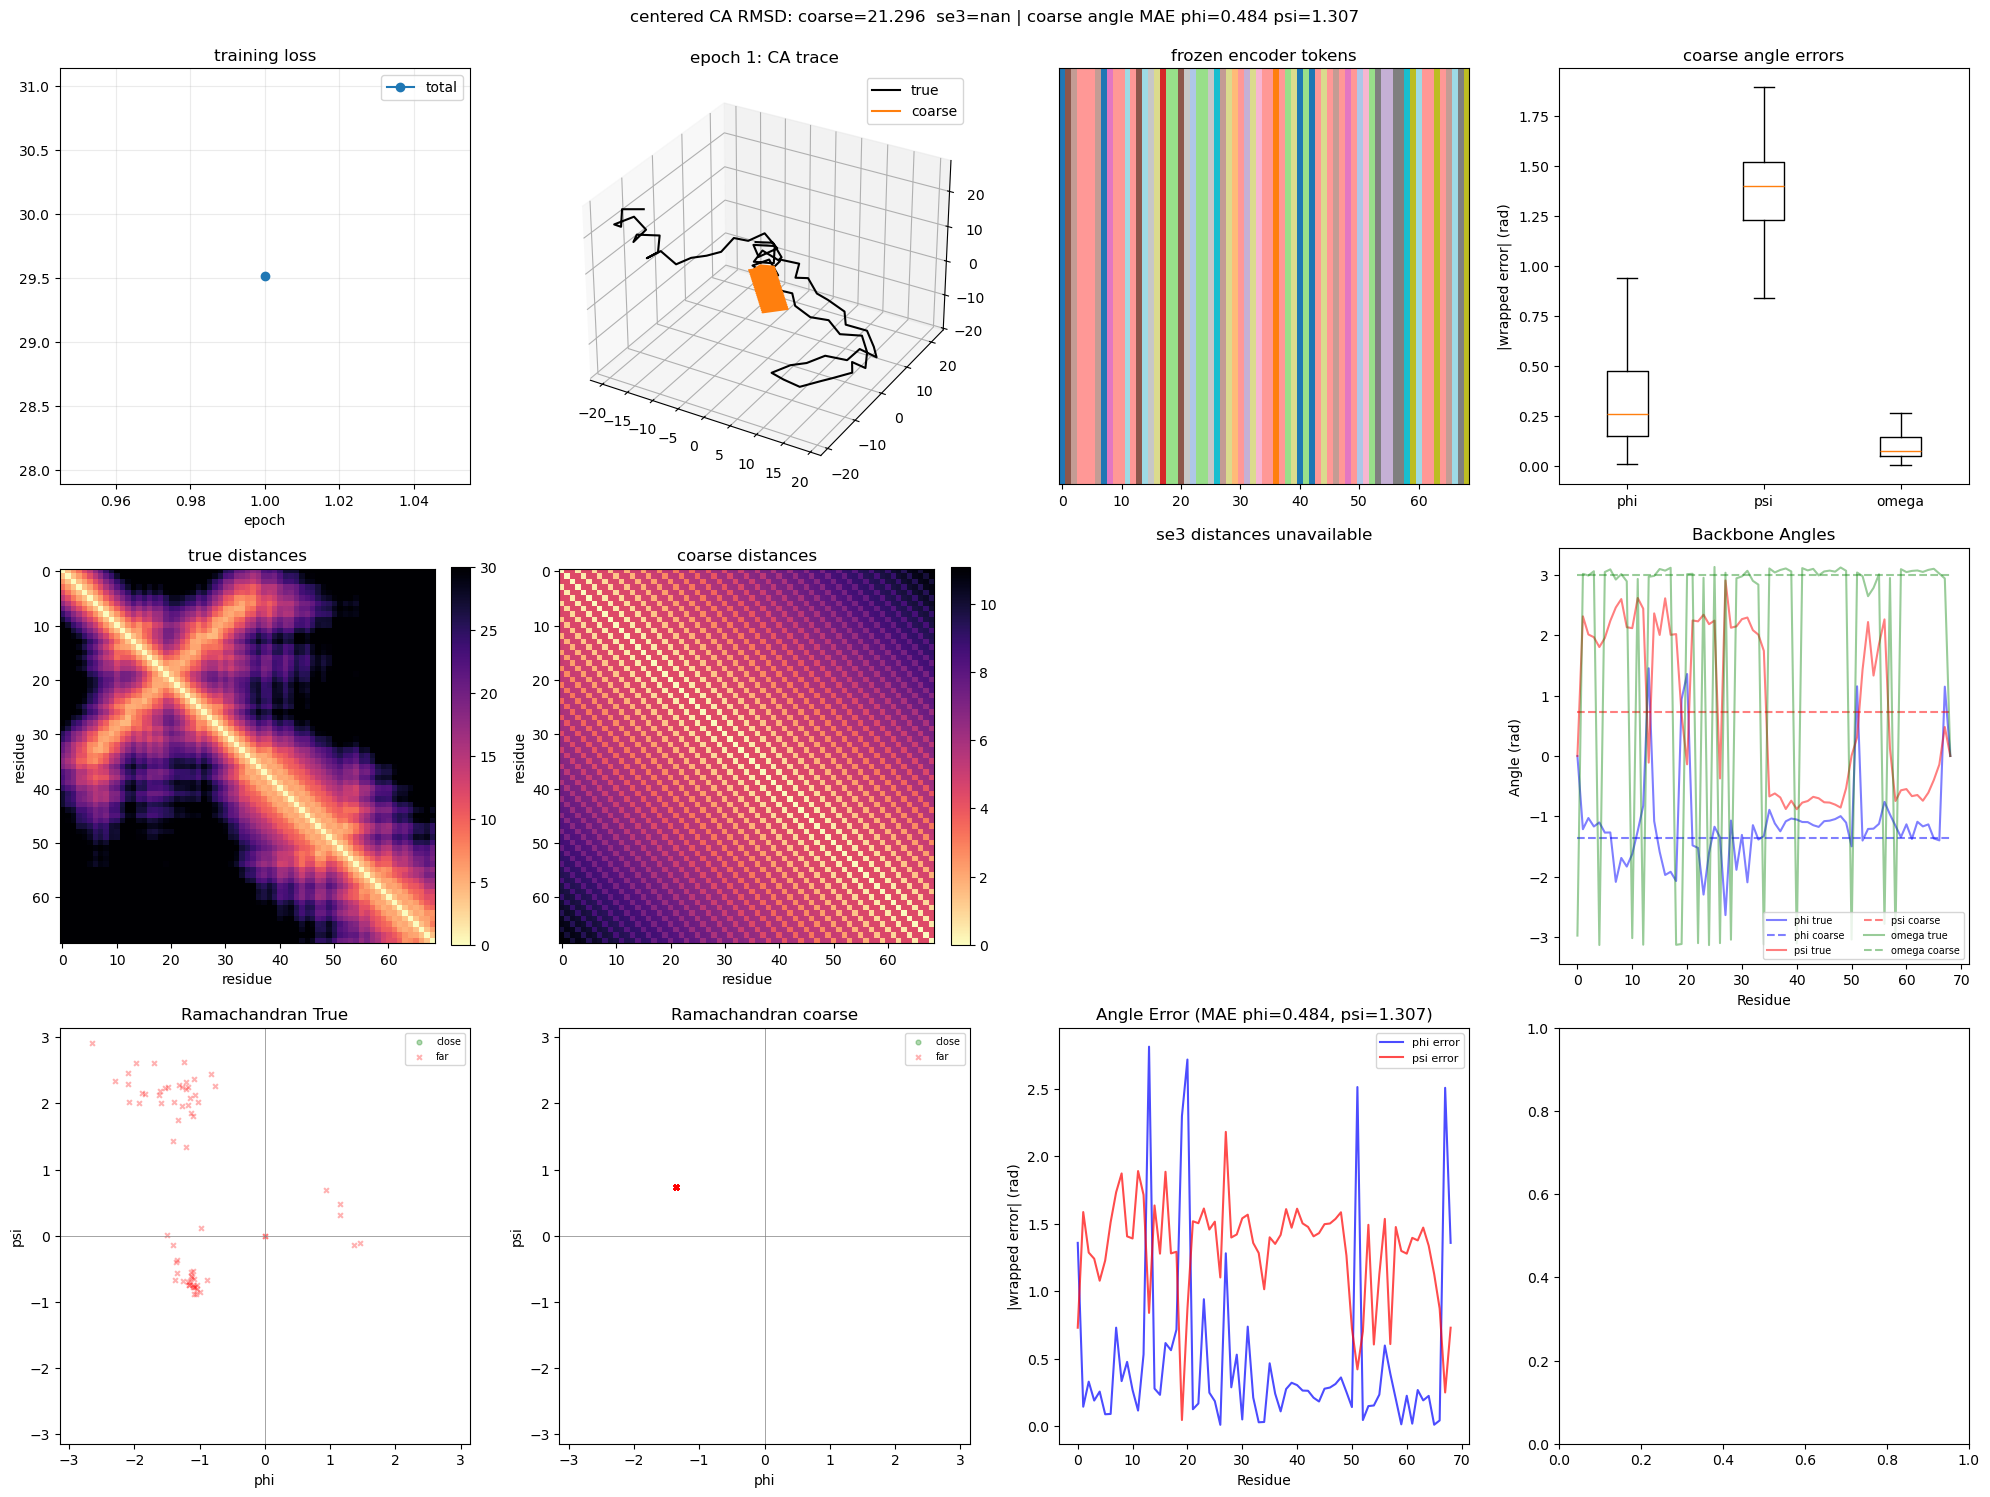

epoch=1 loss=29.5110 coarse_ca_rmsd=21.296 se3_ca_rmsd=nan phi_mae=0.484 psi_mae=1.307 omega_mae=0.147 angle_close=0.000


 10%|█         | 68/670 [12:33<1:41:50, 10.15s/it]

In [ ]:
from IPython.display import clear_output
import tqdm

history = {
	"epoch": [],
	"loss": [],
	"coarse_ca_rmsd": [],
	"se3_ca_rmsd": [],
	"phi_mae": [],
	"psi_mae": [],
	"omega_mae": [],
	"angle_pair_close_frac": [],
}

for epoch in range(1, cfg.epochs + 1):
	module.train()
	module.encoder.eval()
	losses = []

	for step, batch in enumerate(tqdm.tqdm(loader), start=1):
		if cfg.max_batches_per_epoch is not None and step > cfg.max_batches_per_epoch:
			break
		batch = batch.to(device)
		optimizer.zero_grad(set_to_none=True)
		loss, raw_terms, weighted_terms, _, _ = module._compute_total_loss(batch, debug_label=f"notebook epoch={epoch} step={step}")
		loss.backward()
		if cfg.clip_grad and cfg.clip_grad > 0:
			torch.nn.utils.clip_grad_norm_([p for p in module.parameters() if p.requires_grad], cfg.clip_grad)
		optimizer.step()
		losses.append(float(loss.detach().cpu()))

	mean_loss = float(np.mean(losses)) if losses else np.nan
	snapshot = geometry_snapshot(module, preview_batch)

	clear_output(wait=True)
	preview_history = {
		**history,
		"epoch": [*history["epoch"], epoch],
		"loss": [*history["loss"], mean_loss],
	}
	fig, metrics = plot_geometry_learning(preview_history, snapshot, epoch)
	display(fig)
	plt.close(fig)

	history["epoch"].append(epoch)
	history["loss"].append(mean_loss)
	history["coarse_ca_rmsd"].append(metrics["coarse_ca_rmsd"])
	history["se3_ca_rmsd"].append(metrics["se3_ca_rmsd"])
	history["phi_mae"].append(metrics["phi_mae"])
	history["psi_mae"].append(metrics["psi_mae"])
	history["omega_mae"].append(metrics["omega_mae"])
	history["angle_pair_close_frac"].append(metrics["angle_pair_close_frac"])
	print(
		f"epoch={epoch} loss={mean_loss:.4f} "
		f"coarse_ca_rmsd={metrics['coarse_ca_rmsd']:.3f} se3_ca_rmsd={metrics['se3_ca_rmsd']:.3f} "
		f"phi_mae={metrics['phi_mae']:.3f} psi_mae={metrics['psi_mae']:.3f} "
		f"omega_mae={metrics['omega_mae']:.3f} angle_close={metrics['angle_pair_close_frac']:.3f}"
	)


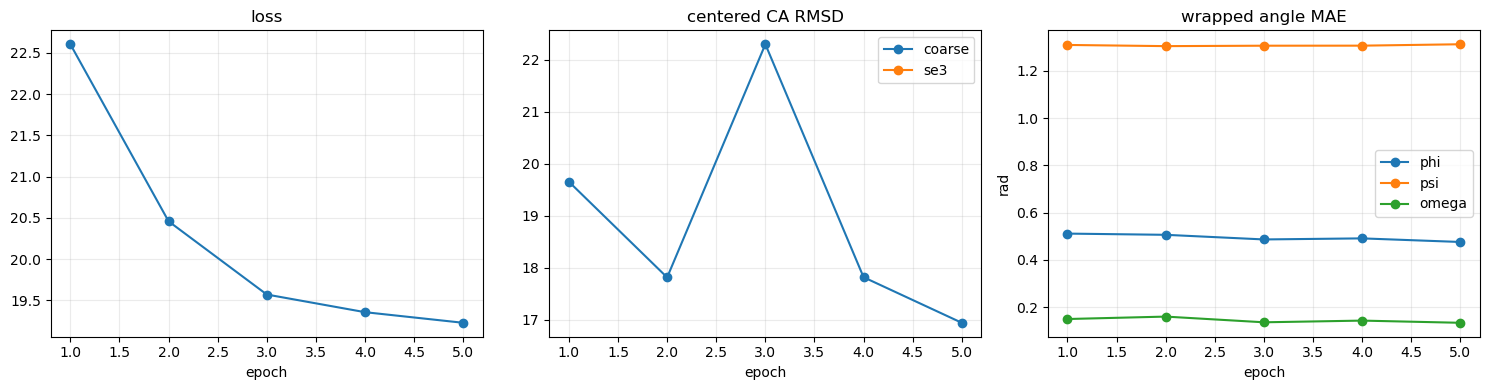

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(history["epoch"], history["loss"], marker="o")
ax[0].set_title("loss")
ax[0].set_xlabel("epoch")
ax[0].grid(alpha=0.25)
ax[1].plot(history["epoch"], history["coarse_ca_rmsd"], marker="o", label="coarse")
ax[1].plot(history["epoch"], history["se3_ca_rmsd"], marker="o", label="se3")
ax[1].set_title("centered CA RMSD")
ax[1].set_xlabel("epoch")
ax[1].legend()
ax[1].grid(alpha=0.25)
ax[2].plot(history["epoch"], history["phi_mae"], marker="o", label="phi")
ax[2].plot(history["epoch"], history["psi_mae"], marker="o", label="psi")
ax[2].plot(history["epoch"], history["omega_mae"], marker="o", label="omega")
ax[2].set_title("wrapped angle MAE")
ax[2].set_xlabel("epoch")
ax[2].set_ylabel("rad")
ax[2].legend()
ax[2].grid(alpha=0.25)
plt.tight_layout()
